<a href="https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/meteoc_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Training Session - CoMet Toolkit: Uncertainties made easy**

# Exercise X: From spectrometer measurements to NDVI with uncertainty propagation.

## Background
In the lab session, repeated spectrometer measurements were taken of:
- astro turf
- cress
- sand
- a Spectralon reference panel

All targets were illuminated using the same lamp.

The Spectralon panel has a known reflectance, so it can be used to convert digital numbers (DNs) measured by the spectrometer into surface reflectance:

$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

In this exercise, we will:
1. Calculate reflectance spectra for astro turf, cress and sand.
2. Propagate uncertainties from repeated measurements and panel reflectance using [**punpy**](https://punpy.readthedocs.io/en/latest/).
3. Integrate the spectra with red and NIR spectral response functions (SRFs).
4. Calculate NDVI.
5. Compare the NDVI values and uncertainties for the three surfaces.

## Learning objectives
By the end of this exercise, you should be able to:
- define a measurement model in Python
- estimate random uncertainty from repeated measurements
- include a systematic uncertainty term from Spectralon reflectance
- use punpy to propagate uncertainty through a multi-step calculation
- calculate NDVI from band-integrated reflectances
- compare NDVI values with uncertainties for different surfaces

## *Step 1* - Set up the environment

First, we again install the punpy package for uncertainty propagation.

In [161]:
!pip install punpy>=1.0.6 matheo

Please hit `Runtime > Restart Session` to properly load these packages into your Google Colab environment...

Then, import the relevant python packages required in this training:

In [162]:
import numpy as np
import matplotlib.pyplot as plt
import punpy
import xarray as xr
import os
from matheo import band_integration

❗Note: If this import fails, it is likely because the pip installation has not properly updated in the Google colab session. Please restart session (in runtime tab above).

## *Step 2* - Load and Inspect the Measurement Data

The dataset contains repeated spectromter measuremetnts from 600 - 1000 nm for:
   - Spectralon (for calibration purposes)
   - Astro turf
   - Cress
   - Sand

Each target has several (25-75) repeats.

In [179]:
!git clone https://github.com/comet-toolkit/comet_training.git

Cloning into 'comet_training'...


In [ ]:
# Load datasets from NetCDF files
data_dir = "example_data"

spectralon_ds = xr.load_dataset("comet_training/Spectralon.nc")
astroturf_ds = xr.load_dataset("comet_training/Astro_turf.nc")
cress_ds = xr.load_dataset("comet_training/Cress.nc")
sand_ds = xr.load_dataset("comet_training/Sand.nc")

# Extract wavelengths and digital number (DN) data
wavelength = spectralon_ds['wavelength'].values

dn_panel_repeats = spectralon_ds['digital_number'].values / spectralon_ds.attrs['integration_time_ms']      # shape: (n_wavelength, n_panel_repeats)
dn_astroturf_repeats = astroturf_ds['digital_number'].values / astroturf_ds.attrs['integration_time_ms']     # shape: (n_wavelength, n_astroturf_repeats)
dn_cress_repeats = cress_ds['digital_number'].values / cress_ds.attrs['integration_time_ms']             # shape: (n_wavelength, n_cress_repeats)
dn_sand_repeats = sand_ds['digital_number'].values / sand_ds.attrs['integration_time_ms']               # shape: (n_wavelength, n_sand_repeats)

# Placeholder for Spectralon reflectance data
rho_panel = np.ones(wavelength.shape[0])             # shape: (n_wavelength,)
u_rho_panel = 0.01*np.ones(wavelength.shape[0])           # shape: (n_wavelength,)

print("Wavelength shape:", wavelength.shape)
print("Panel repeats:", dn_panel_repeats.shape)
print("Astro-turf repeats:", dn_astroturf_repeats.shape)
print("Cress repeats:", dn_cress_repeats.shape)
print("Sand repeats:", dn_sand_repeats.shape)

Wavelength shape: (1718,)
Panel repeats: (1718, 25)
Astro-turf repeats: (1718, 51)
Cress repeats: (1718, 77)
Sand repeats: (1718, 60)


### Inspect the repeated measurements
First, calculate the mean and standard deviation of the repeated DN measurements for each target.
The standard deviation of repeated measurements will be used to estimate the random measurement noise.

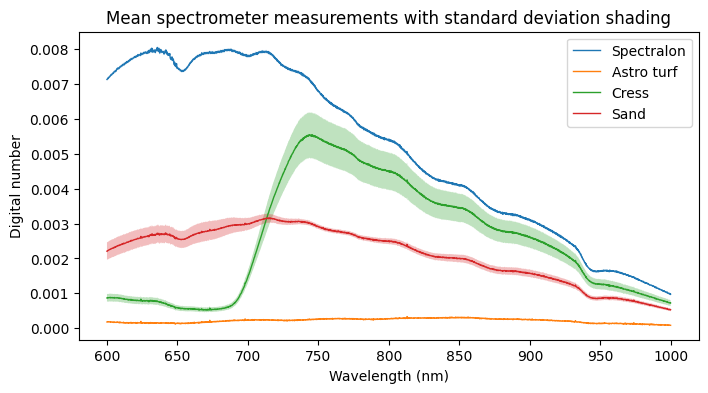

In [164]:
def calculate_stats(dn_repeats):
    """Calculate mean and standard deviation across repeats for each band."""
    mean = np.mean(dn_repeats, axis=1)
    std = np.std(dn_repeats, axis=1, ddof=1)
    return mean, std

# Calculate mean and std for each target
dn_panel_mean, dn_panel_std = calculate_stats(dn_panel_repeats)
dn_astroturf_mean, dn_astroturf_std = calculate_stats(dn_astroturf_repeats)
dn_cress_mean, dn_cress_std = calculate_stats(dn_cress_repeats)
dn_sand_mean, dn_sand_std = calculate_stats(dn_sand_repeats)

# Plot the DN measurement data with shaded uncertainty regions
plt.figure(figsize=(8, 4))
plt.plot(wavelength, dn_panel_mean, label="Spectralon", linewidth=1)
plt.fill_between(wavelength, dn_panel_mean - dn_panel_std, dn_panel_mean + dn_panel_std, alpha=0.3)

plt.plot(wavelength, dn_astroturf_mean, label="Astro turf", linewidth=1)
plt.fill_between(wavelength, dn_astroturf_mean - dn_astroturf_std, dn_astroturf_mean + dn_astroturf_std, alpha=0.3)

plt.plot(wavelength, dn_cress_mean, label="Cress", linewidth=1)
plt.fill_between(wavelength, dn_cress_mean - dn_cress_std, dn_cress_mean + dn_cress_std, alpha=0.3)

plt.plot(wavelength, dn_sand_mean, label="Sand", linewidth=1)
plt.fill_between(wavelength, dn_sand_mean - dn_sand_std, dn_sand_mean + dn_sand_std, alpha=0.3)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Digital number")
plt.title("Mean spectrometer measurements with standard deviation shading")
plt.legend()
plt.show()

For this exercise, we consider two main sources of uncertainty:
### Random uncertainty
- repeatability of the DN measurements for the surface
- repeatability of the DN measurements for the Spectralon panel
### Systematic uncertainty
- uncertainty in the Spectralon reflectance

These uncertainty sources affect the reflectance calculation, and will then propagate into the red and NIR band reflectances and finally into NDVI.

## *Step 3* - Define the Measurement Functions

We will use three models:

1. **Surface reflectance** from surface DN, panel DN and panel reflectance:

$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

2. **Band-integrated reflectance** from a reflectance spectrum and an SRF:

$$\rho_{\text{band}} = \frac{\int \rho(\lambda) \cdot \text{SRF}(\lambda) \, d\lambda}{\int \text{SRF}(\lambda) \, d\lambda}$$

3. **NDVI** from red and NIR band reflectances:

$$\text{NDVI} = \frac{\rho_{\text{NIR}} - \rho_{\text{red}}}{\rho_{\text{NIR}} + \rho_{\text{red}}}$$

In [174]:
def reflectance_model(dn_surface, dn_panel, rho_panel):
   return (dn_surface / dn_panel) * rho_panel

def simple_band_integrate(reflectance, wavelength, wl_min, wl_max):
   """
   Simple band integration - average reflectance within wavelength range
   
   :param reflectance: reflectance spectrum
   :param wavelength: wavelengths
   :param wl_min: minimum wavelength for band
   :param wl_max: maximum wavelength for band
   :return: integrated reflectance value
   """
   # Find indices within the wavelength range
   mask = (wavelength >= wl_min) & (wavelength <= wl_max)
   if np.sum(mask) == 0:
      return 0.0
   # Return average reflectance in this band
   return np.mean(reflectance[mask]), wavelength[mask][np.argmin(np.abs(wavelength[mask] - (wl_min + wl_max)/2))]

def band_integrate_s2_b04(reflectance, wavelength):
   """
   Function to perform S2 Band 4 (Red) band integration on reflectance
   
   Sentinel-2 Band 4 (Red): 630-690 nm, central wavelength ~665 nm
   
   :param reflectance: reflectance spectrum
   :param wavelength: wavelengths
   :return: red band reflectance and band center wavelength
   """
   band_center = 665.0
   red_band = simple_band_integrate(reflectance, wavelength, 630, 690)
   return red_band

def band_integrate_s2_b08(reflectance, wavelength):
   """
   Function to perform S2 Band 8 (NIR) band integration on reflectance
   
   Sentinel-2 Band 8 (NIR): 770-900 nm, central wavelength ~835 nm
   
   :param reflectance: reflectance spectrum
   :param wavelength: wavelengths
   :return: NIR band reflectance and band center wavelength
   """
   band_center = 835.0
   nir_band = simple_band_integrate(reflectance, wavelength, 770, 900)
   return nir_band

def ndvi_model(rho_red, rho_nir):
   return (rho_nir - rho_red) / (rho_nir + rho_red)

## *Step 4* - Calculate the Reflectance Spectra for each Target

In [166]:
rho_astroturf = reflectance_model(dn_astroturf_mean, dn_panel_mean, rho_panel)
rho_cress = reflectance_model(dn_cress_mean, dn_panel_mean, rho_panel)
rho_sand = reflectance_model(dn_sand_mean, dn_panel_mean, rho_panel)

## *Step 4* - Propagate Uncertainties to the Reflectance Spectra

In [167]:
prop = punpy.MCPropagation(10000)

u_random_rho_astroturf = prop.propagate_random(
   reflectance_model,
   [dn_astroturf_mean, dn_panel_mean, rho_panel],
   [dn_astroturf_std, dn_panel_std, None]
)
u_syst_rho_astroturf = prop.propagate_systematic(
    reflectance_model,
        [dn_astroturf_mean, dn_panel_mean, rho_panel],
        [None, None, u_rho_panel]
)

u_random_rho_cress = prop.propagate_random(
   reflectance_model,
    [dn_cress_mean, dn_panel_mean, rho_panel],
    [dn_cress_std, dn_panel_std, None]
)
u_syst_rho_cress = prop.propagate_systematic(
    reflectance_model,
     [dn_cress_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

u_random_rho_sand = prop.propagate_random(
   reflectance_model,
    [dn_sand_mean, dn_panel_mean, rho_panel],
    [dn_sand_std, dn_panel_std, None]
)
u_syst_rho_sand = prop.propagate_systematic(
    reflectance_model,
     [dn_sand_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

In [168]:
# Calculate total uncertainty by combining random and systematic components
u_rho_astroturf = np.sqrt(u_random_rho_astroturf**2 + u_syst_rho_astroturf**2)
u_rho_cress = np.sqrt(u_random_rho_cress**2 + u_syst_rho_cress**2)
u_rho_sand = np.sqrt(u_random_rho_sand**2 + u_syst_rho_sand**2)


# Print summary statistics of uncertainties for each target
surfaces = {
    "Astro turf": (u_random_rho_astroturf, u_syst_rho_astroturf),
    "Cress": (u_random_rho_cress, u_syst_rho_cress),
    "Sand": (u_random_rho_sand, u_syst_rho_sand)
}

for surface, (u_random, u_syst) in surfaces.items():
    u_total = np.sqrt(u_random**2 + u_syst**2)
    print(f"\n{surface}:")
    print(f"  Random uncertainty:     mean={u_random.mean():.4e}, min={u_random.min():.4e}, max={u_random.max():.4e}")
    print(f"  Systematic uncertainty: mean={u_syst.mean():.4e}, min={u_syst.min():.4e}, max={u_syst.max():.4e}")
    print(f"  Total uncertainty:      mean={u_total.mean():.4e}, min={u_total.min():.4e}, max={u_total.max():.4e}")


Astro turf:
  Random uncertainty:     mean=4.5690e-03, min=1.3921e-03, max=1.1783e-02
  Systematic uncertainty: mean=5.3126e-04, min=1.5687e-04, max=1.0625e-03
  Total uncertainty:      mean=4.6002e-03, min=1.4056e-03, max=1.1813e-02

Cress:
  Random uncertainty:     mean=7.0482e-02, min=8.0191e-03, max=1.0245e-01
  Systematic uncertainty: mean=5.9266e-03, min=6.5772e-04, max=8.4193e-03
  Total uncertainty:      mean=7.0731e-02, min=8.0482e-03, max=1.0279e-01

Sand:
  Random uncertainty:     mean=2.7367e-02, min=8.8824e-03, max=4.3195e-02
  Systematic uncertainty: mean=4.4038e-03, min=3.0655e-03, max=5.4111e-03
  Total uncertainty:      mean=2.7792e-02, min=9.8513e-03, max=4.3518e-02


In [169]:
# Define a helper function to plot spectra with uncertainty
def plot_spectrum_with_uncertainty(wavelength, rho, u_rho, label, ax=None):
   if ax is None:
      fig, ax = plt.subplots(figsize=(6, 3))
      show_plot = True
   else:
      show_plot = False
   
   ax.plot(wavelength, rho, label=label, linewidth=2)
   ax.fill_between(wavelength, rho - u_rho, rho + u_rho, alpha=0.3)
   ax.set_xlabel("Wavelength (nm)")
   ax.set_ylabel("Reflectance")
   ax.legend()
   
   if show_plot:
      ax.set_title(f"{label} reflectance with uncertainty")
      plt.show()

def plot_uncertainty_components(wavelength, u_random, u_syst, label, ax=None, percent=False, rho=None, ylim=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
        show_plot = True
    else:
        show_plot = False

    if ylim is not None:
        ax.set_ylim(ylim)

    if percent:
      u_random = 100 * u_random / rho
      u_syst = 100 * u_syst / rho
    ax.plot(wavelength, u_random, label="Random uncertainty", linestyle='--', linewidth=0.5)
    ax.plot(wavelength, u_syst, label="Systematic uncertainty", linestyle='--', linewidth=0.5)
    ax.plot(wavelength, np.sqrt(u_random**2 + u_syst**2), label="Total uncertainty", linewidth=0.5)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Uncertainty in Reflectance (%)" if percent else "Uncertainty in Reflectance")
    ax.set_title(f"Uncertainty Components for {label}")
    ax.legend()
    if show_plot:
        plt.show()

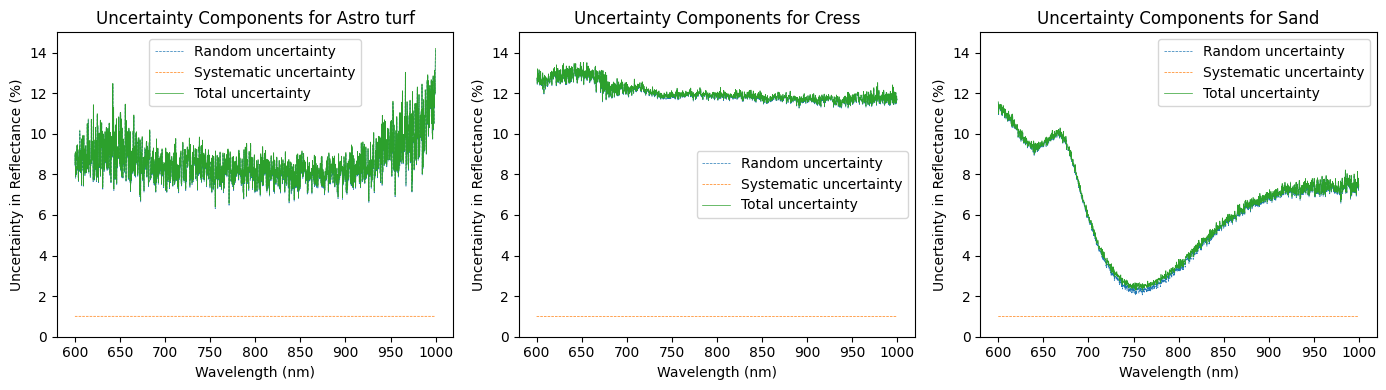

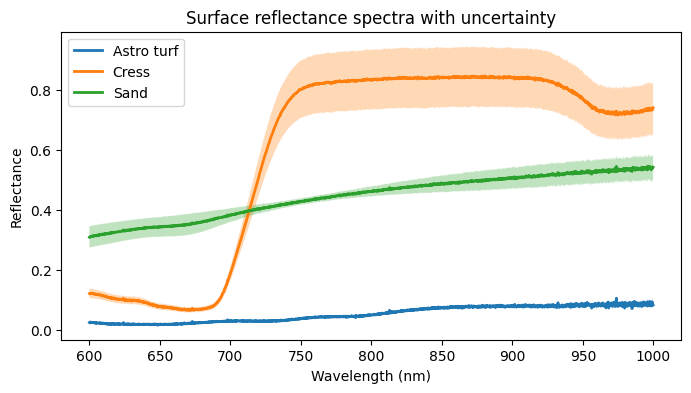

In [170]:
# Plot uncertainty components for each target as subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_uncertainty_components(wavelength, u_random_rho_astroturf, u_syst_rho_astroturf, "Astro turf", ax=axes[0], percent=True, rho=rho_astroturf, ylim=(0, 15))
plot_uncertainty_components(wavelength, u_random_rho_cress, u_syst_rho_cress, "Cress", ax=axes[1], percent=True, rho=rho_cress, ylim=(0, 15))
plot_uncertainty_components(wavelength, u_random_rho_sand, u_syst_rho_sand, "Sand", ax=axes[2], percent=True, rho=rho_sand, ylim=(0, 15))
plt.tight_layout()
plt.show()

# Plot spectra with uncertainty for each target
fig, ax = plt.subplots(figsize=(8, 4))
plot_spectrum_with_uncertainty(wavelength, rho_astroturf, u_rho_astroturf, "Astro turf", ax=ax)
plot_spectrum_with_uncertainty(wavelength, rho_cress, u_rho_cress, "Cress", ax=ax)
plot_spectrum_with_uncertainty(wavelength, rho_sand, u_rho_sand, "Sand", ax=ax)
ax.set_title("Surface reflectance spectra with uncertainty")
plt.show()

## *Step 4* - Integrate over Red and NIR Spectral Response Functions, and Propagate Uncertainties

In [177]:
# Band integration for Sentinel-2 bands
rho_astroturf_b04 = band_integrate_s2_b04(rho_astroturf, wavelength)
rho_astroturf_b08 = band_integrate_s2_b08(rho_astroturf, wavelength)
rho_cress_b04 = band_integrate_s2_b04(rho_cress, wavelength)
rho_cress_b08 = band_integrate_s2_b08(rho_cress, wavelength)
rho_sand_b04 = band_integrate_s2_b04(rho_sand, wavelength)
rho_sand_b08 = band_integrate_s2_b08(rho_sand, wavelength)

print(f"\nBand-integrated reflectance values:")
print(f"  Astro turf - Red: {rho_astroturf_b04[0]:.4f} at {rho_astroturf_b04[1]:.1f} nm")
print(f"  Astro turf - NIR: {rho_astroturf_b08[0]:.4f} at {rho_astroturf_b08[1]:.1f} nm")
print(f"  Cress - Red:      {rho_cress_b04[0]:.4f} at {rho_cress_b04[1]:.1f} nm")
print(f"  Cress - NIR:      {rho_cress_b08[0]:.4f} at {rho_cress_b08[1]:.1f} nm")
print(f"  Sand - Red:       {rho_sand_b04[0]:.4f} at {rho_sand_b04[1]:.1f} nm")
print(f"  Sand - NIR:       {rho_sand_b08[0]:.4f} at {rho_sand_b08[1]:.1f} nm")


Band-integrated reflectance values:
  Astro turf - Red: 0.0210 at 660.1 nm
  Astro turf - NIR: 0.0648 at 834.9 nm
  Cress - Red:      0.0780 at 660.1 nm
  Cress - NIR:      0.8380 at 834.9 nm
  Sand - Red:       0.3492 at 660.1 nm
  Sand - NIR:       0.4782 at 834.9 nm


In [178]:
# Propagate uncertainties through band integration
u_random_rho_astroturf_red = prop.propagate_random(
    band_integrate_s2_b04,
    [rho_astroturf, wavelength],
    [u_random_rho_astroturf, None],
    )
u_random_rho_astroturf_nir = prop.propagate_random(
    band_integrate_s2_b08,
    [rho_astroturf, wavelength],
    [u_random_rho_astroturf, None],
    )

u_syst_rho_astroturf_red = prop.propagate_systematic(
    band_integrate_s2_b04,
    [rho_astroturf, wavelength],
    [u_syst_rho_astroturf, None],
    )
u_syst_rho_astroturf_nir = prop.propagate_systematic(
    band_integrate_s2_b08,
    [rho_astroturf, wavelength],
    [u_syst_rho_astroturf, None],
    )

# Do the same for cress and sand
u_random_rho_cress_red = prop.propagate_random(
    band_integrate_s2_b04,
    [rho_cress, wavelength],
    [u_random_rho_cress, None],
    )
u_random_rho_cress_nir = prop.propagate_random(
    band_integrate_s2_b08,
    [rho_cress, wavelength],
    [u_random_rho_cress, None],
    )
u_syst_rho_cress_red = prop.propagate_systematic(
    band_integrate_s2_b04,
    [rho_cress, wavelength],
    [u_syst_rho_cress, None],
    )
u_syst_rho_cress_nir = prop.propagate_systematic(
    band_integrate_s2_b08,
    [rho_cress, wavelength],
    [u_syst_rho_cress, None],
    )

u_random_rho_sand_red = prop.propagate_random(
    band_integrate_s2_b04,
    [rho_sand, wavelength],
    [u_random_rho_sand, None],
    )

u_random_rho_sand_nir = prop.propagate_random(
    band_integrate_s2_b08,
    [rho_sand, wavelength],
    [u_random_rho_sand, None],
    )

u_syst_rho_sand_red = prop.propagate_systematic(
    band_integrate_s2_b04,
    [rho_sand, wavelength],
    [u_syst_rho_sand, None],
    )
u_syst_rho_sand_nir = prop.propagate_systematic(    
    band_integrate_s2_b08,
    [rho_sand, wavelength],
    [u_syst_rho_sand, None],
    )

print('uncertainties propagated through band integration:')
print(f"  Astro turf - Red: {u_random_rho_astroturf_red}")
print(f"  Astro turf - NIR: {u_random_rho_astroturf_nir}")
print(f"  Cress - Red:      {u_random_rho_cress_red}")
print(f"  Cress - NIR:      {u_random_rho_cress_nir}")
print(f"  Sand - Red:       {u_random_rho_sand_red}")
print(f"  Sand - NIR:       {u_random_rho_sand_nir}")

uncertainties propagated through band integration:
  Astro turf - Red: [1.16729014e-04 6.83257895e-11]
  Astro turf - NIR: [2.25839518e-04 1.13573151e-10]
  Cress - Red:      [6.12943361e-04 6.83257895e-11]
  Cress - NIR:      [4.27097470e-03 1.13573151e-10]
  Sand - Red:       [2.01186264e-03 6.83257895e-11]
  Sand - NIR:       [1.04132650e-03 1.13573151e-10]


## *Step 4* - Calculate NDVI and Propagate Uncertainties

In [160]:
# Calculate NDVI for each target
ndvi_astroturf = ndvi_model(rho_astroturf_b04, rho_astroturf_b08)
ndvi_cress = ndvi_model(rho_cress_b04, rho_cress_b08)
ndvi_sand = ndvi_model(rho_sand_b04, rho_sand_b08)

print(f"\nNDVI values:")
print(f"  Astro turf:  {ndvi_astroturf:.4f}")
print(f"  Cress:       {ndvi_cress:.4f}")
print(f"  Sand:        {ndvi_sand:.4f}")

TypeError: unsupported operand type(s) for -: 'tuple' and 'tuple'

In [130]:
# Propagate uncertainties through NDVI calculation using punpy's Monte Carlo sampling
u_random_ndvi_astroturf = prop.propagate_random(
    ndvi_model,
    [rho_astroturf_b04, rho_astroturf_b08],
    [u_random_rho_astroturf_red, u_random_rho_astroturf_nir]
)
u_syst_ndvi_astroturf = prop.propagate_systematic(
    ndvi_model,
    [rho_astroturf_b04, rho_astroturf_b08],
    [u_syst_rho_astroturf_red, u_syst_rho_astroturf_nir]
)
u_random_ndvi_cress = prop.propagate_random(
    ndvi_model,
    [rho_cress_b04, rho_cress_b08],
    [u_random_rho_cress_red, u_random_rho_cress_nir]
)
u_syst_ndvi_cress = prop.propagate_systematic(
    ndvi_model,
    [rho_cress_b04, rho_cress_b08],
    [u_syst_rho_cress_red, u_syst_rho_cress_nir]
)
u_random_ndvi_sand = prop.propagate_random(
    ndvi_model,
    [rho_sand_b04, rho_sand_b08],
    [u_random_rho_sand_red, u_random_rho_sand_nir]
)
u_syst_ndvi_sand = prop.propagate_systematic(
    ndvi_model,
    [rho_sand_b04, rho_sand_b08],
    [u_syst_rho_sand_red, u_syst_rho_sand_nir]
)



ValueError: operands could not be broadcast together with shapes (10000,) (2,) 

## *Step 4* - Visualise and Compare NDVI Values with Uncertainties

## *Optional Extension* - End-to-End Measurement Function

The entire processing chain (spectrometer-measured DN → reflectance spectra $\rho(\lambda)$ → red and NIR band reflectances $\rho_{\text{red}}$, $\rho_{\text{NIR}}$ → NDVI) can be combined into a single end-to-end measurement function. This approach allows uncertainties to be propagated in one step, rather than at each intermediate stage.

**Benefits:**
- Simplified uncertainty propagation workflow
- All correlations between intermediate steps are automatically captured
- More efficient computation for complex processing chains

**Try it yourself:** Write a single measurement function that takes the raw DN measurements and returns the final NDVI, incorporating all three models presented above.

In [ ]:
# Define your end-to-end measurement function here
# This function should take raw DN measurements as input and return NDVI as output

def end_to_end_ndvi(dn_surface, dn_panel, rho_panel, rho_spectrum, srf_red, srf_nir):
    """
    Calculate NDVI from raw spectrometer measurements in one step.
    
    Parameters:
    -----------
    dn_surface : array-like
        Surface measurement digital numbers
    dn_panel : array-like
        Panel measurement digital numbers
    rho_panel : array-like
        Panel reflectance spectrum
    rho_spectrum : array-like
        Reflectance spectrum of the surface
    srf_red : array-like
        Red band spectral response function
    srf_nir : array-like
        NIR band spectral response function
        
    Returns:
    --------
    ndvi : float
        Normalized Difference Vegetation Index
    """
    # TODO: Implement the end-to-end function
    pass

In [ ]:
# Propagate uncertainties through the end-to-end measurement function
# TODO: Initialize a punpy propagation object and apply the end_to_end_ndvi function
# to calculate NDVI with uncertainty propagation

# Consider which uncertainty sources should be included:
# - Random uncertainties from DN measurements
# - Systematic uncertainties from panel reflectance
# - Any other relevant uncertainty components

# Steps:
# 1. Create a punpy propagation object (e.g., MCPropagation with appropriate number of samples)
# 2. Call the propagation method with end_to_end_ndvi and your input data with uncertainties
# 3. Compare the results with the step-by-step propagation approach

ndvi_e2e = None  # Replace with your propagation result
ndvi_e2e_unc = None  # Replace with uncertainty estimate